In [13]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

In [14]:
#set the directory local to this file as to where to look for the output files
prefix="slices/"

In [15]:
#import the meansvariances file
#format is time, field 0 mean, field 0 variance, field 1 mean, field 1 variance, etc
meansvariances = np.genfromtxt(prefix+"meansvariances.dat")

#split this into an array for means and variance
numflds=int((len(meansvariances[1])-1)/2)

times = meansvariances[:,0]
means = meansvariances[:,np.arange(1,numflds*2+1,2)]
variances = meansvariances[:,np.arange(2,numflds*2+2,2)]

#import the slices-time file
slicestime = np.genfromtxt(prefix+"slices_time.dat")

#extract the important information
scalefactor = slicestime[:,1] #scale factor, a
hubble = slicestime[:,3]
kinetic = slicestime[:,4]
potential = slicestime[:,5]
gradient = slicestime[:,6]
rho = slicestime[:,7]

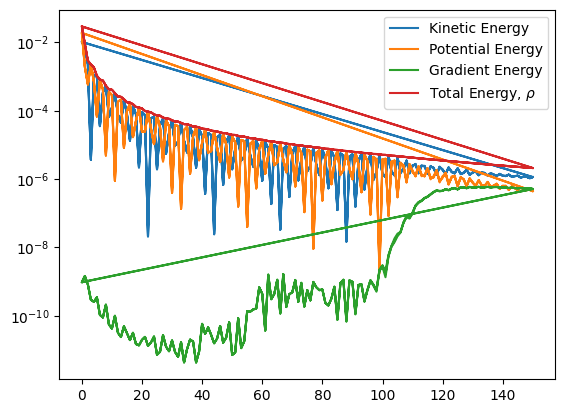

In [16]:
#you can plot any number of the homogenous information

fig, ax = plt.subplots()

#plt.plot(times,scalefactor,label="Scale Factor")
#plt.plot(times,hubble,label="Hubble Parameter")
plt.plot(times,kinetic,label="Kinetic Energy")
plt.plot(times,potential,label="Potential Energy")
plt.plot(times,gradient,label="Gradient Energy")
plt.plot(times,rho,label=r"Total Energy, $\rho$")

ax.set_yscale('log')
plt.legend()

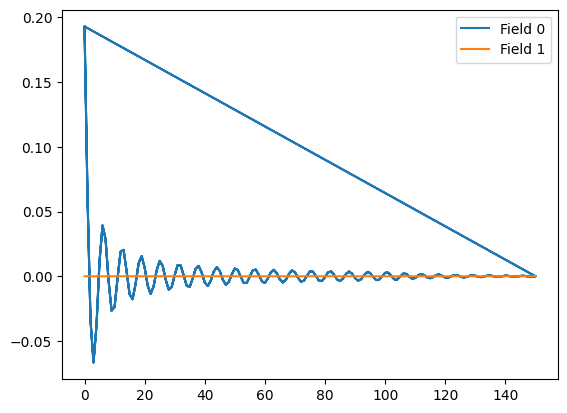

In [17]:
#Now plot the means of the fields

fig, ax = plt.subplots()

for i in np.arange(numflds):
    plt.plot(times,means[:,i],label="Field "+str(i))
    
plt.legend()

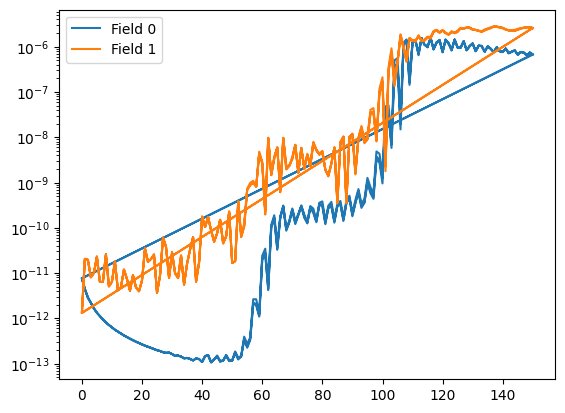

In [18]:
fig, ax = plt.subplots()

for i in np.arange(numflds):
    plt.plot(times,variances[:,i],label="Field "+str(i))

ax.set_yscale('log')
plt.legend()

#plt.savefig("variances.pdf")

In [20]:
#now let's import the spectra
spectra = []

for i in np.arange(len(times)):
    spectra.append(np.genfromtxt(prefix+"slices_spectra_"+str(i)+".dat"))

FileNotFoundError: slices/slices_spectra_151.dat not found.

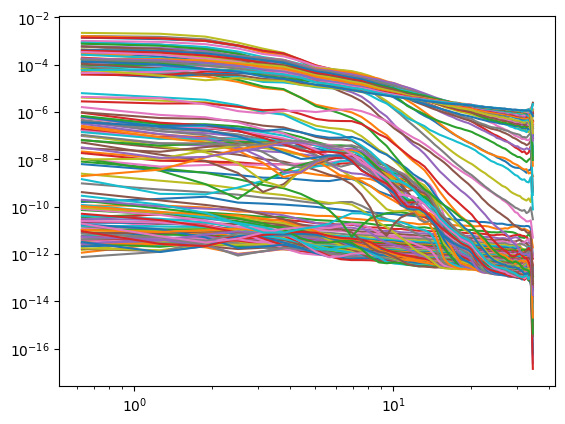

In [8]:
#plot them all, just for fun
#this is the regular power spectrum

fig, ax = plt.subplots()

whichfield = 0 #which field

for spec in spectra:
    plt.plot(spec[1:,0],spec[1:,whichfield*2+1])

ax.set_xscale('log')
ax.set_yscale('log')

#plt.legend()

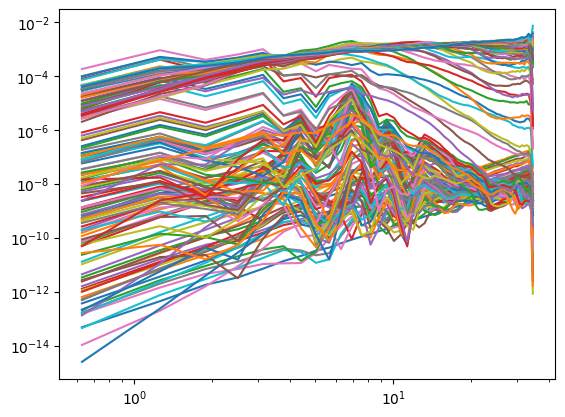

In [9]:
#plot them all, just for fun
#this is the DIMENSIONLESS power spectrum

fig, ax = plt.subplots()

whichfield = 1 #which field

for spec in spectra:
    plt.plot(spec[1:,0],spec[1:,whichfield*2+2])

ax.set_xscale('log')
ax.set_yscale('log')

#plt.legend()

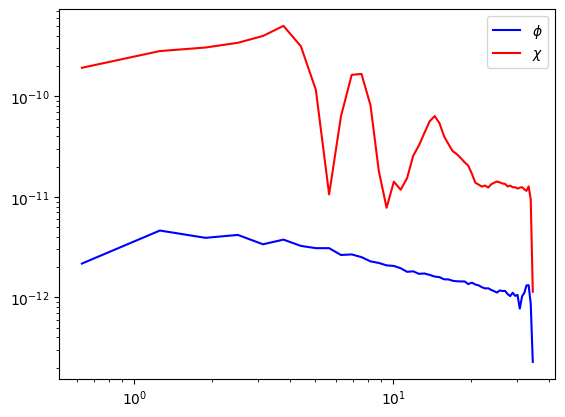

In [10]:
## If you turned on GW's!

fig, ax = plt.subplots()

whichslice = 15 #choose which slice to plot

plt.plot(spectra[whichslice][1:,0],spectra[whichslice][1:,0*2+1],label=r"$\phi$",c="blue")
plt.plot(spectra[whichslice][1:,0],spectra[whichslice][1:,1*2+1],label=r"$\chi$",c="red")

ax.set_xscale('log')
ax.set_yscale('log')
plt.legend()


In [12]:
##if you want to plot a 2-d slice of a 3-d slice file

N=32
L=3
whichfield = 0 #which field 0 for phi, 1 for chi, 2 for rho (if 2-fld model)
whichslice = 3
deltax=L/N

plot=np.genfromtxt(prefix+"slices_fields_"+str(whichslice)+".dat")[:,whichfield].reshape(N,N,N)
#find maximum 
max_index = np.unravel_index(np.argmax(plot), plot.shape)

#create grid
# Generate a 3D field (example: a 2D Gaussian function over a grid)
x = np.linspace(0,L,N)#L,deltax)
y = np.linspace(0,L,N)#deltax)
X, Y = np.meshgrid(x, y)

#print(x)

# Plot the 3D surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, plot[max_index[0]], cmap='viridis')
#ax.contour3D(X, Y, plot[max_index[0]], 50, cmap='viridis')

ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.set_title("3D Surface Plot")
plt.show()


ValueError: cannot reshape array of size 1024 into shape (32,32,32)